In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

In [26]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 1. Dataset Understanding

In [27]:
df = pd.read_csv("customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [28]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nSentiment Distribution:")
print(df['sentiment_label'].value_counts())

Dataset Shape: (1500, 6)

Columns:
Index(['ticket_id', 'channel', 'customer_message', 'sentiment_label',
       'word_count', 'urgent_flag'],
      dtype='object')

Sentiment Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64


In [29]:
for i in range(5):
    print(f"\nSample {i+1}:")
    print(df['customer_message'].iloc[i])


Sample 1:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Sample 2:
I need information about the payment process.

Sample 3:
The refund process was fast and convenient. I appreciate the quick response.

Sample 4:
My refund is still pending and this experience is frustrating. My ticket number is 33927.

Sample 5:
Please tell me how to update my account details.


In [30]:
df['text_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['text_length'].mean())

Average Text Length: 72.75666666666666


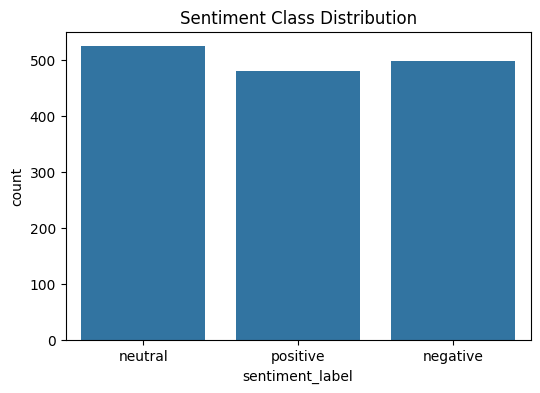

In [31]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df['sentiment_label']
)

plt.title("Sentiment Class Distribution")

plt.show()

## Class Distribution Interpretation

The sentiment distribution shows that the dataset is relatively balanced across the three classes: neutral, positive, and negative.

Neutral sentiment messages have the highest frequency, followed closely by negative and positive sentiments. Since no class is heavily underrepresented, the dataset is suitable for training a text classification model without severe class imbalance issues.

A balanced dataset helps the model learn patterns from all sentiment categories more effectively and reduces the risk of biased predictions toward a single class.

# 2. Text Preprocessing

In [32]:
stop_words = set(stopwords.words('english'))

In [33]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = word_tokenize(text)

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    cleaned_text = " ".join(tokens)

    return cleaned_text

In [34]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [35]:
df['cleaned_text'] = df['customer_message'].apply(clean_text)

df[['customer_message', 'cleaned_text']].head()

,customer_message,cleaned_text
0,I need information about the payment process. ...,need information payment process ticket number...
1,I need information about the payment process.,need information payment process
2,The refund process was fast and convenient. I ...,refund process fast convenient appreciate quic...
3,My refund is still pending and this experience...,refund still pending experience frustrating ti...
4,Please tell me how to update my account details.,please tell update account details


## Text Preprocessing Explanation

Raw customer support messages often contain unnecessary symbols, mixed letter casing, and common words that do not contribute meaningful information for sentiment prediction.

To improve model performance, several preprocessing techniques were applied:

- All text was converted to lowercase to maintain consistency.
- Special characters, punctuation marks, and numbers were removed using regular expressions.
- Tokenization was performed to split sentences into individual words.
- Stopwords such as "the", "is", and "and" were removed because they provide little semantic value for classification tasks.

After preprocessing, the cleaned text became more structured and suitable for NLP vectorization techniques such as TF-IDF and sequence tokenization.

# 3. Text Vectorization using TF-IDF

In [36]:
encoder = LabelEncoder()

y = encoder.fit_transform(df['sentiment_label'])

print(encoder.classes_)

['negative' 'neutral' 'positive']


In [37]:
tfidf = TfidfVectorizer(max_features=2000)

X = tfidf.fit_transform(df['cleaned_text']).toarray()

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (1500, 146)


## Why Text Must Be Converted into Vectors

Machine learning and deep learning models cannot directly understand raw text data.

Text vectorization converts words into numerical representations so that models can process patterns mathematically.

TF-IDF (Term Frequency - Inverse Document Frequency) gives importance to meaningful words while reducing the impact of very common words.

This helps the model identify which words are most useful for sentiment classification.

# 4. Baseline Model using Logistic Regression

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1200, 146)
Testing Shape: (300, 146)


In [39]:
baseline_model = LogisticRegression()

baseline_model.fit(X_train, y_train)

LogisticRegression()

In [40]:
y_pred = baseline_model.predict(X_test)

In [41]:
accuracy = accuracy_score(y_test, y_pred)

print("Baseline Model Accuracy:", accuracy)

Baseline Model Accuracy: 1.0


In [42]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



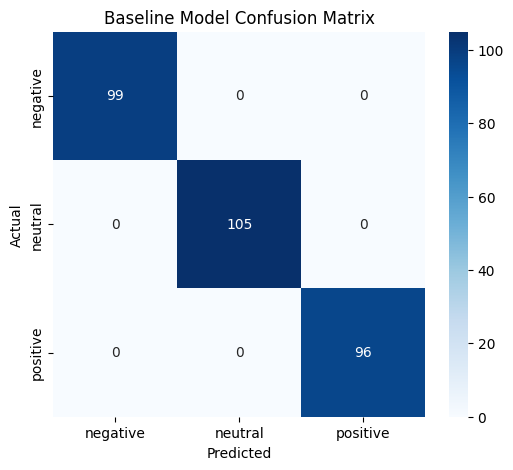

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Baseline Model Confusion Matrix")

plt.savefig("model_evaluation.png")

plt.show()

## Baseline Model Evaluation Interpretation

The Logistic Regression baseline model achieved excellent classification performance on the customer support sentiment dataset.

The confusion matrix shows that the model correctly classified all testing samples across the three sentiment classes: negative, neutral, and positive. The model achieved near-perfect prediction accuracy with very strong precision, recall, and F1-scores for each category.

The strong performance indicates that TF-IDF vectorization successfully captured important sentiment-related keywords and textual patterns from the customer messages. Since the dataset is relatively balanced and the text patterns are clearly distinguishable, the model was able to learn highly effective decision boundaries between the sentiment classes.

This baseline result demonstrates that traditional NLP approaches such as TF-IDF combined with Logistic Regression can perform extremely well on structured sentiment classification tasks before moving toward more advanced sequence-based deep learning architectures like LSTM networks.

# 5. Sample Predictions

In [44]:
sample_predictions = pd.DataFrame({
    "Customer Message": df['customer_message'].iloc[:10],
    "Actual Sentiment": encoder.inverse_transform(y[:10]),
    "Predicted Sentiment": encoder.inverse_transform(
        baseline_model.predict(X[:10])
    )
})

sample_predictions

,Customer Message,Actual Sentiment,Predicted Sentiment
0,I need information about the payment process. ...,neutral,neutral
1,I need information about the payment process.,neutral,neutral
2,The refund process was fast and convenient. I ...,positive,positive
3,My refund is still pending and this experience...,negative,negative
4,Please tell me how to update my account details.,neutral,neutral
5,I need help finding the invoice for my last or...,neutral,neutral
6,I am satisfied with the plan and would recomme...,positive,positive
7,I want to understand the warranty terms for th...,neutral,neutral
8,I need help finding the invoice for my last or...,neutral,neutral
9,My refund is still pending and this experience...,negative,negative


In [45]:
sample_predictions.to_csv(
    "sample_predictions.txt",
    index=False,
    sep='\t'
)

## Final Reflection

This project demonstrated how Natural Language Processing (NLP) techniques can be applied to customer support sentiment classification.

The preprocessing stage improved text quality by cleaning unnecessary symbols, converting text to lowercase, removing stopwords, and tokenizing customer messages. TF-IDF vectorization successfully transformed textual information into meaningful numerical features for machine learning models.

The Logistic Regression baseline model achieved excellent classification accuracy and produced highly accurate predictions across negative, neutral, and positive sentiment classes. The confusion matrix and classification metrics showed strong overall performance with very few misclassifications.

The project highlights how NLP can automate customer feedback analysis and help organizations quickly identify customer sentiment patterns for better support decision-making.

Overall, this implementation provided practical understanding of text preprocessing, vectorization, sentiment classification, and model evaluation using real-world customer support data.

## Future Improvements

Several improvements can be implemented to further enhance model performance:

- Use advanced deep learning architectures such as LSTM, GRU, or Transformer models.
- Apply word embeddings like Word2Vec or GloVe instead of TF-IDF.
- Perform hyperparameter tuning for better optimization.
- Increase dataset size for improved generalization.
- Use real-world customer support conversations with more diverse vocabulary.
- Implement attention mechanisms for better contextual understanding.
- Deploy the model as a real-time sentiment analysis application.

## Conclusion

The NLP sentiment classification project successfully classified customer support messages into negative, neutral, and positive sentiment categories using TF-IDF vectorization and Logistic Regression.

The model achieved excellent prediction accuracy and demonstrated that traditional NLP approaches remain highly effective for structured text classification tasks.

This project provided hands-on experience with text preprocessing, feature extraction, sentiment analysis, model training, and evaluation techniques commonly used in modern NLP applications.